# Spectral light-curve pipeline (reusable for different targets)

Builds an **emission-line** light curve and a **5100 Å continuum** light curve from a
set of AGN-only, rest-frame spectra. Point it at a new target by editing the
**Configuration** cell only (paths + window variables).

The cells below follow the requested order:

1. **Mean & RMS spectra** from the `*_combined.txt` spectra; define the line / continuum / 5100 Å **windows**.
2. **Linear continuum subtraction** under the line window to isolate the line flux.
3. **Integrate** the line flux (Simpson) and **average** the 5100 Å flux.
4. Repeat 2–3 on the individual **per-night exposures** to get the same-night **scatter**.
5. **Median-filter** residual to capture the rapid-variability uncertainty.
6. **Sum all errors in quadrature**.
7. **Save** the line and 5100 Å light curves.

Input spectra are expected as 3 columns: `wavelength (Å)  flux  flux_err`.

## Configuration — edit this block for a new target

`INPUT_DIR` must contain the AGN-only, **rest-frame** spectra: both the per-epoch
combined spectra (`*_combined.txt`) and the individual per-night exposures
(`*fits.cali.txt`). `FLUX_LST` supplies the Julian Date of each epoch.

In [177]:
import os
import ast
import numpy as np
from matplotlib import pyplot as plt
from scipy.integrate import simpson
from scipy.stats import linregress
from scipy.ndimage import median_filter

# =====================================================================
# CONFIGURATION  --  edit this block for a new target / emission line
# =====================================================================

TARGET    = "NGC3227"          # used for plot titles only
LINE_NAME = "hbeta"            # label for the line light curve + output file name

# Directory of AGN-only, REST-FRAME spectra. Must hold BOTH the per-epoch
# combined spectra and the individual per-night exposures.
# Each file: 3 columns -> wavelength (A), flux, flux_err.
INPUT_DIR = "/Users/kaiwenzhang/Desktop/NGC 3227/Halpha_analysis/agn_only_dered_spectra"

# Directory holding the per-night exposures (defaults to INPUT_DIR).
EXPOSURE_DIR = INPUT_DIR

# Epoch list + Julian Dates. First whitespace column = combined-spectrum
# filename, second column = JD. A header line is tolerated (it is skipped).
FLUX_LST = "/Users/kaiwenzhang/Desktop/NGC 3227/NGC3227/flux.lst"

# Directory holding the RAW combined spectra whose header line
#   '#  combined spec: [...]'
# lists the exact exposures that were stacked into each combined spectrum.
# Step 4 measures the per-night scatter ONLY on those exposures (so extra
# same-night exposures that were NOT stacked are ignored). Defaults to the
# folder containing flux.lst.
RAW_COMBINED_DIR = os.path.dirname(FLUX_LST)

# Where the light curves are written.
OUTPUT_DIR = os.getcwd()

# ---- File-name conventions -------------------------------------------------
COMBINED_PATTERN = "_combined.txt"   # marks a per-epoch combined spectrum
EXPOSURE_PATTERN = "fits.raw.txt"   # marks an individual per-night exposure
# Skip any spectrum whose filename contains one of these substrings.
EXCLUDE_SUBSTR = ["rebin", ".out", "20200205"]   # 20200205 = bad night (NGC3227)

# ---- Spectral windows (rest-frame, Angstrom)  ==  THE WINDOWS VARIABLES =====
# Defaults below are NGC 3227 H-beta. Change these for a different line/target.
LINE_WINDOW = (4800.0, 4929.0)   # emission line to integrate
CONT_BLUE   = (4750.0, 4790.0)   # blue continuum anchor (mean flux taken here)
CONT_RED    = (5075.0, 5125.0)   # red  continuum anchor (mean flux taken here)
WIN_5100    = (5075.0, 5125.0)   # window whose mean flux defines the "5100 A" point

# ---- Error-budget options --------------------------------------------------
MEDIAN_FILTER_SIZE    = 5        # kernel for the rapid-variability estimate
MEDIAN_FILTER_ON_LINE = True
MEDIAN_FILTER_ON_5100 = True     # apply the median-filter term to both LCs

plt.rcParams.update({"figure.dpi": 110, "font.size": 12})
print(f"Target: {TARGET} | line: {LINE_NAME}")
print(f"Input : {INPUT_DIR}")
print(f"Output: {OUTPUT_DIR}")

Target: NGC3227 | line: hbeta
Input : /Users/kaiwenzhang/Desktop/NGC 3227/Halpha_analysis/agn_only_dered_spectra
Output: /Users/kaiwenzhang/PycharmProjects/NGC3227


### Helpers: spectrum loader and epoch list

In [178]:
def load_spectrum(path):
    """Return (wavelength, flux, err) sorted by wavelength.

    Robust to either (N, 3) column layout or (3, N) row layout.
    """
    arr = np.loadtxt(path)
    if arr.ndim != 2:
        raise ValueError(f"Spectrum {path} is not 2-D (shape {arr.shape}).")
    if arr.shape[1] == 3:        # (N, 3): columns are wl, flux, err
        lam, flux, err = arr.T
    elif arr.shape[0] == 3:      # (3, N): rows are wl, flux, err
        lam, flux, err = arr
    else:
        raise ValueError(f"Spectrum {path} is not 3-column (shape {arr.shape}).")
    order = np.argsort(lam)
    return lam[order], flux[order], err[order]


def _excluded(name):
    return any(s in name for s in EXCLUDE_SUBSTR)


def read_used_exposures(combined_name):
    """List the raw exposures that were stacked into a combined spectrum.

    Parses the '#  combined spec: [...]' header line of the raw combined file
    in RAW_COMBINED_DIR. Returns the list of exposure filenames, or None if the
    file / header is unavailable.
    """
    path = os.path.join(RAW_COMBINED_DIR, combined_name)
    if not os.path.exists(path):
        return None
    with open(path) as f:
        for line in f:
            if not line.startswith("#"):      # header sits above the data rows
                break
            if "combined spec:" in line:
                payload = line.split("combined spec:", 1)[1].strip()
                try:
                    return list(ast.literal_eval(payload))
                except (ValueError, SyntaxError):
                    return None
    return None


def read_epochs(flux_lst):
    """Read (name, jd) for the combined epochs, sorted by JD.

    Only keeps rows whose filename contains COMBINED_PATTERN, is not excluded,
    and whose combined spectrum actually exists in INPUT_DIR.
    """
    names, jds = [], []
    with open(flux_lst) as f:
        for line in f:
            parts = line.split()
            if len(parts) < 2:
                continue
            name = parts[0]
            if COMBINED_PATTERN not in name or _excluded(name):
                continue
            try:
                jd = float(parts[1])
            except ValueError:        # header / non-numeric line
                continue
            if not os.path.exists(os.path.join(INPUT_DIR, name)):
                print(f"  [skip] {name}: not found in INPUT_DIR")
                continue
            names.append(name)
            jds.append(jd)
    order = np.argsort(jds)
    names = [names[i] for i in order]
    jds = np.asarray([jds[i] for i in order], dtype=float)
    return names, jds


epoch_names, jd = read_epochs(FLUX_LST)
print(f"{len(epoch_names)} epochs | JD {jd.min():.2f} -> {jd.max():.2f}")

73 epochs | JD 2458803.01 -> 2458999.73


In [ ]:
def read_syserr(combined_name):
    """Fractional systematic error of a combined epoch, parsed from its raw
    header line in RAW_COMBINED_DIR:

        #  jd: <jd>  syserr: [v1 v2 v3 ...]

    The bracket lists the per-exposure fractional residuals about the stack mean.
    Mirrors `readspec` in code_lc.py:

        syserr = std(values, ddof=1) / sqrt(N)        # standard error of the mean

    i.e. the uncertainty on the epoch's *mean* flux scale (not the spread of one
    exposure), so it shrinks as more exposures are stacked. Returns 0.0 when the
    header/values are missing or there is only one exposure (N<2 -> no scatter).
    """
    path = os.path.join(RAW_COMBINED_DIR, combined_name)
    if not os.path.exists(path):
        return 0.0
    with open(path) as f:
        for line in f:
            if not line.startswith("#"):       # header sits above the data rows
                break
            if "syserr:" in line:
                try:
                    payload = line.split("syserr:", 1)[1]
                    vals = [float(x) for x in
                            payload.split("[", 1)[1].split("]", 1)[0].split()]
                except (IndexError, ValueError):
                    return 0.0
                if len(vals) > 1:
                    return np.std(vals, ddof=1) / np.sqrt(len(vals))
                return 0.0
    return 0.0


# Fractional systematic error per epoch (aligned with epoch_names / jd).
syserr = np.array([read_syserr(name) for name in epoch_names])
print(f"syserr parsed: {np.count_nonzero(syserr > 0)}/{len(syserr)} epochs nonzero")
print(f"  example {epoch_names[0]} -> {syserr[0]:.4e}")
print(f"  median (nonzero) syserr = {np.median(syserr[syserr > 0]):.4e}  (fractional)")

## Step 1 — Mean & RMS spectra + define the windows

Stack all combined spectra, compute the pixel-wise mean and RMS, and overlay the
configured windows so you can confirm/adjust them visually before measuring.

In [179]:
wl = None
fluxes = []
for name in epoch_names:
    lam, flux, err = load_spectrum(os.path.join(INPUT_DIR, name))
    if wl is None:
        wl = lam
    elif len(lam) != len(wl) or not np.allclose(lam, wl):
        raise ValueError(f"{name} is on a different wavelength grid; "
                         "resample the spectra onto a common grid first.")
    fluxes.append(flux)

fluxes = np.array(fluxes)
mean_flux = fluxes.mean(axis=0)
rms_flux = fluxes.std(axis=0)          # population std (ddof=0) across epochs
print(f"Stacked {fluxes.shape[0]} spectra x {fluxes.shape[1]} pixels")

Stacked 73 spectra x 1907 pixels


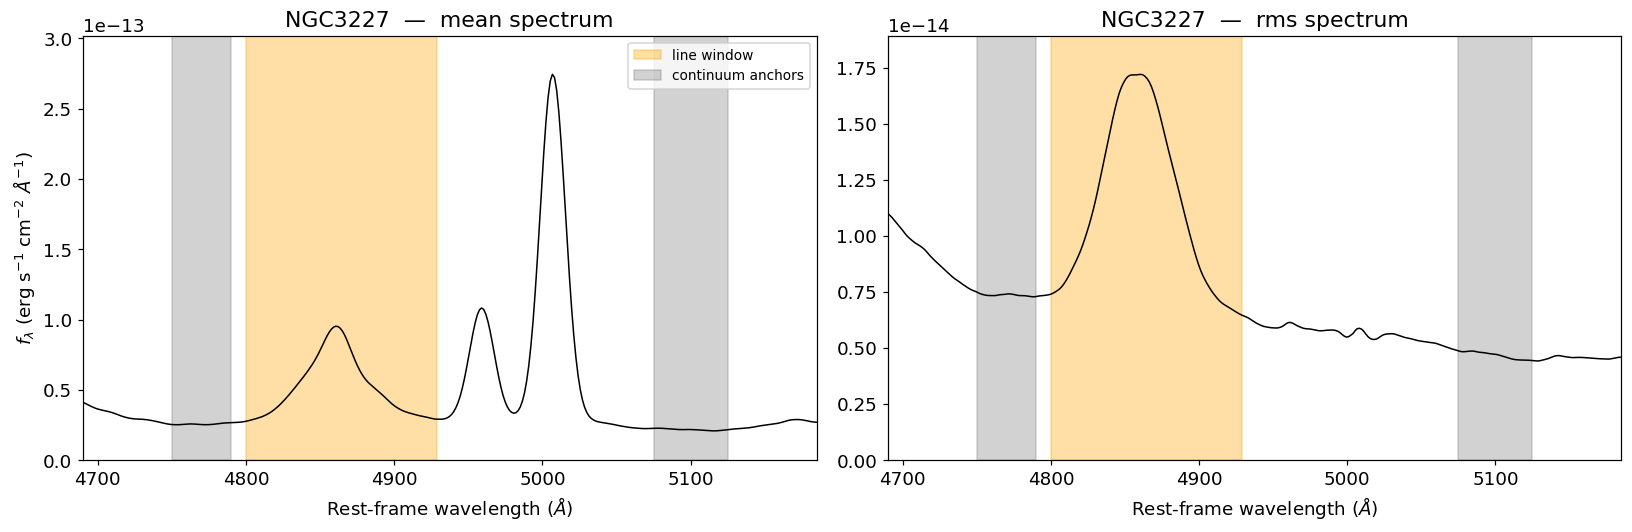

In [180]:
def shade_windows(ax):
    ax.axvspan(*LINE_WINDOW, color="orange", alpha=0.35, label="line window")
    ax.axvspan(*CONT_BLUE, color="grey", alpha=0.35, label="continuum anchors")
    ax.axvspan(*CONT_RED, color="grey", alpha=0.35)
    if tuple(WIN_5100) != tuple(CONT_RED):
        ax.axvspan(*WIN_5100, color="green", alpha=0.20, label="5100 window")


lo = min(CONT_BLUE[0], LINE_WINDOW[0]) - 60
hi = max(CONT_RED[1], WIN_5100[1], LINE_WINDOW[1]) + 60
zoom = (wl >= lo) & (wl <= hi)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, (spec, title) in zip(axes, [(mean_flux, "mean"), (rms_flux, "rms")]):
    ax.plot(wl, spec, c="k", lw=1)
    shade_windows(ax)
    ax.set_xlim(lo, hi)
    ax.set_ylim(0, np.nanmax(spec[zoom]) * 1.1)
    ax.set_xlabel(r"Rest-frame wavelength ($\AA$)")
    ax.set_title(f"{TARGET}  —  {title} spectrum")
axes[0].set_ylabel(r"$f_\lambda$ (erg s$^{-1}$ cm$^{-2}$ $\AA^{-1}$)")
axes[0].legend(fontsize=9, loc="upper right")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "spec_mean_rms.pdf"))
plt.show()

## Step 2 — Linear continuum subtraction

Fit a straight line through the mean flux of the blue and red anchor windows
(anchored at each window's center) and subtract it under the line window. What
remains is the isolated emission-line flux.

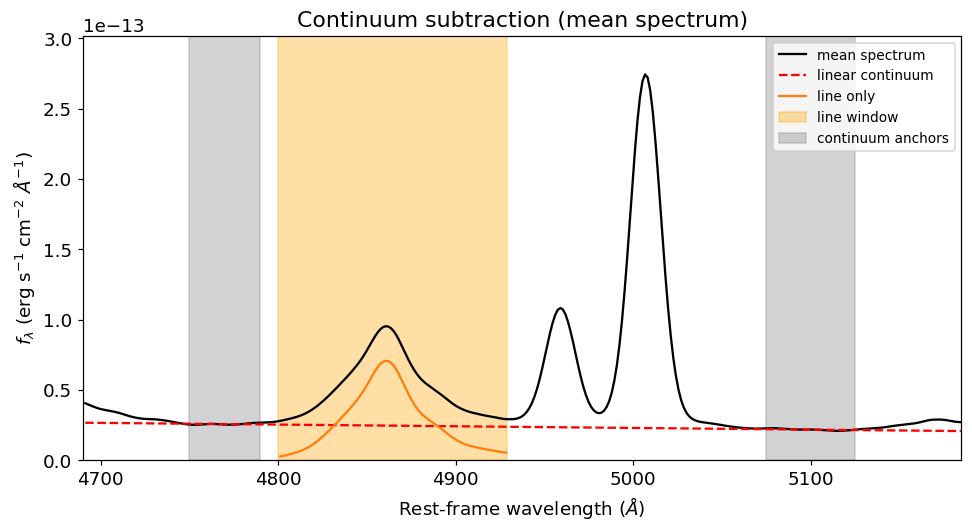

In [181]:
def subtract_local_continuum(lam, flux):
    """Linear pseudo-continuum from the blue & red anchors, subtracted under
    LINE_WINDOW. Returns (line_only, continuum_model)."""
    x_blue = 0.5 * (CONT_BLUE[0] + CONT_BLUE[1])
    x_red = 0.5 * (CONT_RED[0] + CONT_RED[1])
    f_blue = flux[(lam >= CONT_BLUE[0]) & (lam <= CONT_BLUE[1])].mean()
    f_red = flux[(lam >= CONT_RED[0]) & (lam <= CONT_RED[1])].mean()
    slope, intercept, *_ = linregress([x_blue, x_red], [f_blue, f_red])
    continuum = slope * lam + intercept

    line_only = np.zeros_like(flux)
    m = (lam >= LINE_WINDOW[0]) & (lam <= LINE_WINDOW[1])
    line_only[m] = flux[m] - continuum[m]
    return line_only, continuum


# Demo on the mean spectrum
mean_line, mean_cont = subtract_local_continuum(wl, mean_flux)
m_line = (wl >= LINE_WINDOW[0]) & (wl <= LINE_WINDOW[1])

plt.figure(figsize=(9, 5))
plt.plot(wl[zoom], mean_flux[zoom], c="k", label="mean spectrum")
plt.plot(wl[zoom], mean_cont[zoom], "r--", label="linear continuum")
plt.plot(wl[m_line], mean_line[m_line], c="tab:orange", label="line only")
shade_windows(plt.gca())
plt.xlim(lo, hi)
plt.ylim(0, np.nanmax(mean_flux[zoom]) * 1.1)
plt.xlabel(r"Rest-frame wavelength ($\AA$)")
plt.ylabel(r"$f_\lambda$ (erg s$^{-1}$ cm$^{-2}$ $\AA^{-1}$)")
plt.legend(fontsize=9)
plt.title("Continuum subtraction (mean spectrum)")
plt.tight_layout()
plt.show()

## Step 3 — Integrate the line, average the 5100 Å flux

For every epoch (combined spectrum): Simpson-integrate the continuum-subtracted
line over the line window, and take the mean flux in the 5100 Å window. The
**spectral** error is propagated from the err column.

In [182]:
def _quadrature_weights(lam):
    """Trapezoidal integration weights w_i (units of lam) such that
    sum(w_i * f_i) == integral of f over lam. Valid for uniform or
    non-uniform wavelength grids."""
    w = np.empty_like(lam, dtype=float)
    w[1:-1] = 0.5 * (lam[2:] - lam[:-2])
    w[0] = 0.5 * (lam[1] - lam[0])
    w[-1] = 0.5 * (lam[-1] - lam[-2])
    return w


def integrate_line(lam, flux, err):
    """Integrated line flux (continuum subtracted) + propagated error.

    F        = integral of f dlambda            (Simpson)
    sigma_F  = sqrt( sum( (w_i * sigma_i)^2 ) ) with trapezoidal weights w_i,
    so sigma_F has the same units as F (erg s^-1 cm^-2).
    """
    line_only, _ = subtract_local_continuum(lam, flux)
    m = (lam >= LINE_WINDOW[0]) & (lam <= LINE_WINDOW[1])
    flux_line = simpson(line_only[m], lam[m])
    w = _quadrature_weights(lam[m])
    err_line = np.sqrt(np.sum((w * err[m]) ** 2))
    return flux_line, err_line


def average_5100(lam, flux, err):
    """Mean flux in the 5100 A window + spectral error of the mean."""
    m = (lam >= WIN_5100[0]) & (lam <= WIN_5100[1])
    n = np.count_nonzero(m)
    flux_c = flux[m].mean()
    err_c = np.sqrt(np.sum(err[m] ** 2)) / n
    return flux_c, err_c


line_flux, line_err_spec = [], []
c5100_flux, c5100_err_spec = [], []
for name in epoch_names:
    lam, flux, err = load_spectrum(os.path.join(INPUT_DIR, name))
    f_line, e_line = integrate_line(lam, flux, err)
    f_c, e_c = average_5100(lam, flux, err)
    line_flux.append(f_line)
    line_err_spec.append(e_line)
    c5100_flux.append(f_c)
    c5100_err_spec.append(e_c)

line_flux = np.array(line_flux)
line_err_spec = np.array(line_err_spec)
c5100_flux = np.array(c5100_flux)
c5100_err_spec = np.array(c5100_err_spec)
print(f"Measured {len(line_flux)} epochs.")

Measured 73 epochs.


## Step 4 — Per-night scatter from the raw exposures

For each epoch we use **only the exposures that were actually stacked** into the
combined spectrum — read from the `#  combined spec: [...]` header of the raw
combined file (`RAW_COMBINED_DIR`). Extra same-night exposures that were not
stacked are ignored. We run the **same** Steps 2–3 on each used exposure and take
the standard deviation across them. Epochs with <2 used exposures get a scatter of 0.

If a combined file has no such header, we fall back to all same-night
`EXPOSURE_PATTERN` files and print a warning.

In [183]:
all_exposures = [f for f in os.listdir(EXPOSURE_DIR)
                 if EXPOSURE_PATTERN in f and not _excluded(f)]
print(f"{len(all_exposures)} per-night exposure files in EXPOSURE_DIR.")

line_scatter, c5100_scatter, n_used = [], [], []
for name in epoch_names:
    used_raw = read_used_exposures(name)
    used = [ i.split('.')[0] + f'.{EXPOSURE_PATTERN}' for i in used_raw ] # correct to the format used for per night exposures
    if used is None:                                  # no header -> fall back
        used = [f for f in all_exposures if f.startswith(name[:8])]
        print(used)
        print(f"  [warn] {name}: no 'combined spec' header; using all "
              f"{len(used)} same-night exposures.")

    f_lines, f_cs = [], []
    
    for exp in used:
        epath = os.path.join(EXPOSURE_DIR, exp)
        if not os.path.exists(epath):
            print(f"  [warn] {name}: stacked exposure not found in "
                  f"EXPOSURE_DIR: {exp}")
            continue
        lam, flux, err = load_spectrum(epath)
        f_lines.append(integrate_line(lam, flux, err)[0])
        f_cs.append(average_5100(lam, flux, err)[0])

    # sample std (ddof=1): unbiased dispersion estimate for small N
    n_used.append(len(f_lines))
    line_scatter.append(np.nanstd(f_lines, ddof=1) if len(f_lines) > 1 else 0.0)
    c5100_scatter.append(np.nanstd(f_cs, ddof=1) if len(f_cs) > 1 else 0.0)

line_scatter = np.array(line_scatter)
c5100_scatter = np.array(c5100_scatter)
n_used = np.array(n_used)
print(f"exposures per epoch: min={n_used.min()} max={n_used.max()} "
      f"median={int(np.median(n_used))}")
print(f"median per-night scatter  line={np.median(line_scatter):.3e}  "
      f"5100={np.median(c5100_scatter):.3e}")

0 per-night exposure files in EXPOSURE_DIR.
  [warn] 20191114_combined.txt: stacked exposure not found in EXPOSURE_DIR: 20191114_a092otbfww2msf.fits.raw.txt
  [warn] 20191114_combined.txt: stacked exposure not found in EXPOSURE_DIR: 20191114_a093otbfww2msf.fits.raw.txt
  [warn] 20191114_combined.txt: stacked exposure not found in EXPOSURE_DIR: 20191114_a094otbfww2msf.fits.raw.txt
  [warn] 20191118_combined.txt: stacked exposure not found in EXPOSURE_DIR: 20191118_a099otbfww2msf.fits.raw.txt
  [warn] 20191118_combined.txt: stacked exposure not found in EXPOSURE_DIR: 20191118_a100otbfww2msf.fits.raw.txt
  [warn] 20191118_combined.txt: stacked exposure not found in EXPOSURE_DIR: 20191118_a101otbfww2msf.fits.raw.txt
  [warn] 20191122_combined.txt: stacked exposure not found in EXPOSURE_DIR: 20191122_a115otbfww2msf.fits.raw.txt
  [warn] 20191122_combined.txt: stacked exposure not found in EXPOSURE_DIR: 20191122_a116otbfww2msf.fits.raw.txt
  [warn] 20191122_combined.txt: stacked exposure not

## Step 5 — Median-filter rapid-variability term

Smooth each light curve with a median filter and take the std of the residual.
This single scalar estimates excess short-timescale scatter not captured by the
formal errors, and is added to every epoch of that light curve.

In [184]:
def median_filter_scatter(lc, size=MEDIAN_FILTER_SIZE):
    """Std of (lc - median_filtered(lc)): a rapid-variability scatter estimate."""
    lc = np.asarray(lc, dtype=float)
    smooth = median_filter(lc, size=size, mode="nearest")
    return np.std(lc - smooth)


line_median = median_filter_scatter(line_flux) if MEDIAN_FILTER_ON_LINE else 0.0
c5100_median = median_filter_scatter(c5100_flux) if MEDIAN_FILTER_ON_5100 else 0.0
print(f"median-filter term  line={line_median:.3e}  5100={c5100_median:.3e}")

median-filter term  line=8.852e-14  5100=7.090e-16


## Step 6 — Sum all errors in quadrature

`err_total = sqrt(err_spectral² + err_scatter² + err_median² + err_syserr²)` for
each light curve, where `err_syserr = syserr · flux` is the per-epoch flux-scale
systematic parsed from the combined-spectrum header (Step "read_syserr"), exactly
as in `code_lc.py`'s `(syserr*fhb)` / `(syserr*mediancr)` terms.

In [ ]:
# Per-epoch flux-scale systematic: fractional syserr (combined-spectrum header)
# times the epoch flux. Mirrors code_lc.py's (syserr*fhb) / (syserr*mediancr).
line_syserr = syserr * line_flux
c5100_syserr = syserr * c5100_flux

line_err = np.sqrt(line_err_spec ** 2 + line_scatter ** 2
                   + line_median ** 2 + line_syserr ** 2)
c5100_err = np.sqrt(c5100_err_spec ** 2 + c5100_scatter ** 2
                    + c5100_median ** 2 + c5100_syserr ** 2)

print("Median fractional error budget:")
print(f"  line : spec {np.median(line_err_spec/line_flux):.3%} | "
      f"scatter {np.median(line_scatter/line_flux):.3%} | "
      f"median {line_median/np.median(line_flux):.3%} | "
      f"syserr {np.median(line_syserr/line_flux):.3%} | "
      f"total {np.median(line_err/line_flux):.3%}")
print(f"  5100 : spec {np.median(c5100_err_spec/c5100_flux):.3%} | "
      f"scatter {np.median(c5100_scatter/c5100_flux):.3%} | "
      f"median {c5100_median/np.median(c5100_flux):.3%} | "
      f"syserr {np.median(c5100_syserr/c5100_flux):.3%} | "
      f"total {np.median(c5100_err/c5100_flux):.3%}")

## Step 7 — Save the light curves

Written as 3 columns: `JD  flux  flux_err` — ready for CCF / MICA.

wrote /Users/kaiwenzhang/PycharmProjects/NGC3227/lc_hbeta.txt
wrote /Users/kaiwenzhang/PycharmProjects/NGC3227/lc_5100.txt


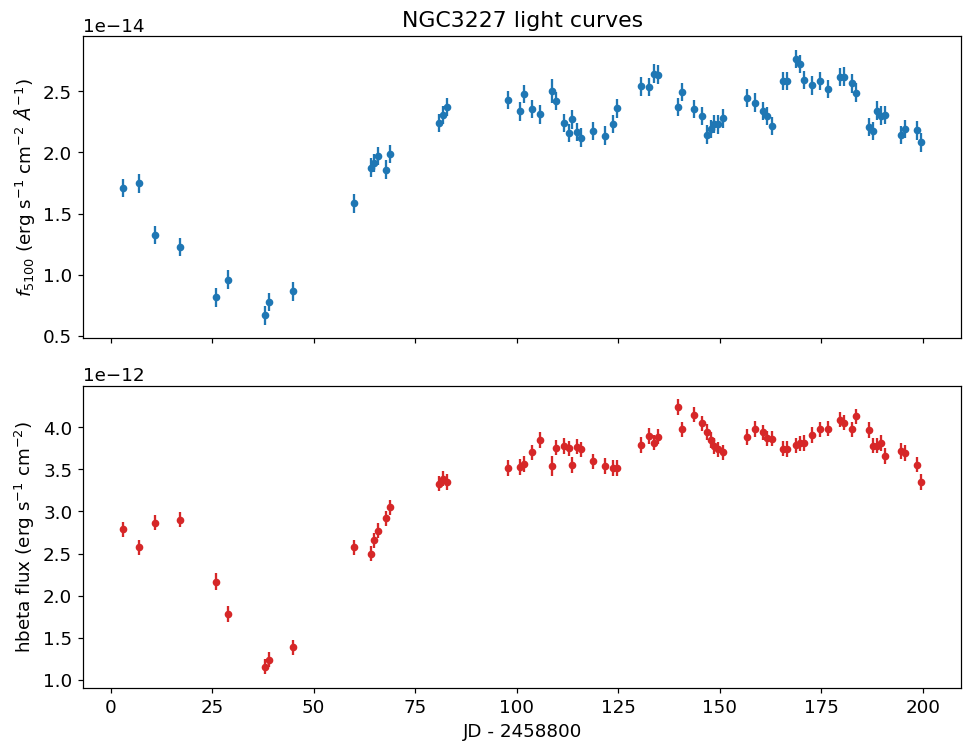

In [186]:
line_out = os.path.join(OUTPUT_DIR, f"lc_{LINE_NAME}.txt")
c5100_out = os.path.join(OUTPUT_DIR, "lc_5100.txt")
np.savetxt(line_out, np.vstack((jd, line_flux, line_err)).T)
np.savetxt(c5100_out, np.vstack((jd, c5100_flux, c5100_err)).T)
print("wrote", line_out)
print("wrote", c5100_out)

t = jd - 2.4588e6
fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)
axes[0].errorbar(t, c5100_flux, c5100_err, fmt="o", ms=4, c="tab:blue")
axes[0].set_ylabel(r"$f_{5100}$ (erg s$^{-1}$ cm$^{-2}$ $\AA^{-1}$)")
axes[1].errorbar(t, line_flux, line_err, fmt="o", ms=4, c="tab:red")
axes[1].set_ylabel(f"{LINE_NAME} flux (erg s$^{{-1}}$ cm$^{{-2}}$)")
axes[1].set_xlabel("JD - 2458800")
axes[0].set_title(f"{TARGET} light curves")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f"light_curves_{LINE_NAME}.pdf"))
plt.show()